# Your RAG demo works. Now prove it.

*Build a RAG pipeline over real contracts, watch it impress you, then measure it against lawyers.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omnifroodle/couchbase_notebooks/blob/main/notebooks/flows/01_rag_that_you_can_trust.ipynb)
[![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/omnifroodle/couchbase_notebooks?quickstart=1)

**Claim.** A RAG pipeline that answers your demo query perfectly can still invent an answer to a quarter of the questions that have none — and one accuracy number will not tell you whether to fix retrieval or generation.
**Result.** In the run stored here: the demo query is answered exactly right. Across 160 judged questions the same pipeline is 64.4% correct, fabricates an answer for 23 of the 93 questions that have none, and never retrieves the evidence for a third of the answerable ones. One paragraph added to the system prompt takes it to 70.6%.
**Requires.** couchbase · llm · local-embeddings
**Read** ~12 min · **Run** ~10 min · **Cost** a few cents

Everyone's first RAG demo works. You load some documents, ask the question you had in mind
while building it, and a well-formed answer comes back with a citation attached. It is genuinely
convincing — and it is close to no evidence at all.

This notebook builds that demo, and then does the thing that separates a prototype from a
system: it asks **820 questions whose answers were written down by lawyers** and counts how
many the pipeline gets right.

The corpus is [CUAD](https://www.atticusprojectai.org/cuad) — 510 commercial contracts filed
with the SEC, annotated by attorneys for 41 categories of clause that matter in a corporate
transaction. Every annotation is a character range, so "did we retrieve the right passage"
is not a matter of opinion.

And it has the property that makes this exercise honest:

> **62% of the questions have no answer in their contract.**

Most contracts have no source-code-escrow clause. The correct response is *"that isn't in this
document"* — which is the hardest thing to get a language model to say, and the one behaviour
a hand-picked demo will never test.

**What this notebook does**

1. Chunks the contracts, embeds them, and indexes them in Couchbase.
2. Runs one convincing query.
3. Runs the whole judged set and watches the number fall.
4. Splits the failures into *retrieval missed it* and *the model ignored it* — different bugs
   with different fixes, indistinguishable without span-level ground truth.
5. Changes one thing, and measures whether it helped.

In [1]:
# --- Setup. Works in a local checkout and on Colab. -------------------------
import os
import pathlib
import subprocess
import sys

# Cloned on Colab, where there is no local checkout. Override to test a fork.
REPO_URL = os.environ.get("CBNB_REPO_URL", "https://github.com/omnifroodle/couchbase_notebooks")

try:
    import cbnb
except ModuleNotFoundError:
    here = pathlib.Path.cwd()
    root = next((p for p in [here, *here.parents] if (p / "cbnb" / "__init__.py").exists()), None)
    if root is None:
        # Colab: clone the repo so the committed datasets come with it.
        subprocess.check_call(["git", "clone", "--depth", "1", "--quiet", REPO_URL, "cbnb-repo"])
        root = pathlib.Path("cbnb-repo").resolve()
    sys.path.insert(0, str(root))
    import cbnb

settings = cbnb.bootstrap(requires=["couchbase", "llm", "local-embeddings"], extras=["plots"])

cbnb ready (local, autoreload on). Couchbase: cb.***.cloud.couchbase.com (bucket 'demos') | LLM: nanogpt/z-ai/glm-5.3 | embeddings: local
Ready for: couchbase, llm, local-embeddings


## 1. Twenty contracts and what lawyers said about them

The committed sample is 20 contracts across 18 kinds of agreement. For each one, 41 clause
categories were reviewed, and where a clause exists its exact character range is recorded.

Look at the last line of the summary before anything else.

In [2]:
from cbnb.datasets import load_cuad

cuad = load_cuad()
print(cuad.summary())

cuad.contracts[["contract_id", "contract_type"]].head(6)

20 contracts, 18 types, 41 clause categories, 534 annotated spans; 62% of questions have no answer in their contract


,contract_id,contract_type
0,0,CONSULTING AGREEMENT
1,1,COOPERATION AGREEMENT
2,2,CONTENT LICENSE AGREEMENT
3,3,DISTRIBUTOR AGREEMENT
4,4,DEVELOPMENT AGREEMENT
5,5,SOFTWARE LICENSE AND MAINTENANCE AGREEMENT


In [3]:
questions = cuad.questions_with_absences()

print(f"question/contract pairs : {len(questions)}")
print(f"  answerable            : {questions.answerable.sum()}")
print(f"  no answer in contract : {(~questions.answerable).sum()}"
      f"  ({(~questions.answerable).mean():.0%})")

cuad.categories.head(5)

question/contract pairs : 820
  answerable            : 309
  no answer in contract : 511  (62%)


,category,question
0,Document Name,What is the name or title of this contract?
1,Parties,Who are the parties to this agreement?
2,Agreement Date,What date was this contract signed?
3,Effective Date,On what date does this agreement become effect...
4,Expiration Date,On what date will the contract's initial term ...


That 62% is the whole reason this notebook exists. If you build a demo by picking a few
questions and checking the answers look right, **you will pick questions that have answers** —
and you will never discover what your system does with the other two thirds.

## 2. Chunk, embed, index

Contracts are 12,000–45,000 characters. No model reads one whole and no retriever should try,
so they get split into overlapping windows.

The overlap matters more than it looks: a clause that straddles a boundary is a clause neither
chunk contains completely. Overlapping windows are the cheap insurance, and 200 characters is
a guess we could and should measure later.

Because we know each chunk's character range, a chunk is *relevant* to a question exactly when
it overlaps a span a lawyer marked. That is our ground truth, and it needs no judgement call.

In [4]:
CHUNK_CHARS = 1200
CHUNK_OVERLAP = 200


def chunk(text, size=CHUNK_CHARS, overlap=CHUNK_OVERLAP):
    """Fixed-width overlapping windows, each carrying its character range."""
    step = size - overlap
    return [
        {"start": start, "end": min(start + size, len(text)), "text": text[start:start + size]}
        for start in range(0, max(len(text) - overlap, 1), step)
    ]


chunks = []
for row in cuad.contracts.itertuples(index=False):
    for number, piece in enumerate(chunk(row.text)):
        chunks.append({
            "chunk_id": f"{row.contract_id}-{number}",
            "contract_id": row.contract_id,
            "contract_type": row.contract_type,
            "title": row.title,
            **piece,
        })

import pandas as pd

chunks = pd.DataFrame(chunks)
print(f"{len(chunks):,} chunks from {len(cuad.contracts)} contracts "
      f"({len(chunks) / len(cuad.contracts):.0f} each on average)")

609 chunks from 20 contracts (30 each on average)


In [5]:
# Ground truth: which chunks overlap a span a lawyer marked.
gold = {}
for span in cuad.spans.itertuples(index=False):
    same = chunks[chunks.contract_id == span.contract_id]
    hits = same[(same.start < span.end) & (same.end > span.start)]
    gold.setdefault((span.contract_id, span.category), set()).update(hits.chunk_id)

sizes = [len(v) for v in gold.values()]
print(f"{len(gold)} answerable questions have gold chunks")
print(f"chunks per answerable question: min {min(sizes)}, median {sorted(sizes)[len(sizes)//2]}, max {max(sizes)}")

309 answerable questions have gold chunks
chunks per answerable question: min 1, median 2, max 7


In [6]:
from cbnb.couchbase_io import connect, ensure_collection, upsert_docs
from cbnb.embeddings import Embedder

BUCKET, SCOPE, COLLECTION, INDEX = settings.cb_bucket, "contracts", "chunks", "contract_chunks"

embedder = Embedder()
vectors = embedder.encode(chunks.text.tolist())

cluster = connect(settings)
collection = ensure_collection(cluster, BUCKET, SCOPE, COLLECTION)
upsert_docs(collection, {
    row.chunk_id: {
        "type": COLLECTION,
        "chunk_id": row.chunk_id,
        "contract_id": int(row.contract_id),
        "contract_key": f"c{row.contract_id}",   # keyword-indexed, so it can be filtered on
        "contract_type": row.contract_type,
        "start": int(row.start),
        "end": int(row.end),
        "text": row.text,
        "embedding": vector.tolist(),
    }
    for row, vector in zip(chunks.itertuples(index=False), vectors)
})

  upserted 200/609

  upserted 400/609

  upserted 600/609

  upserted 609/609

609

In [7]:
from cbnb.couchbase_io import ensure_vector_index, wait_for_index

ensure_vector_index(
    cluster,
    bucket_name=BUCKET, scope_name=SCOPE, collection_name=COLLECTION,
    index_name=INDEX,
    vector_field="embedding", dims=embedder.dims,
    text_fields=["text"],
    keyword_fields=["contract_key", "contract_type"],
)
wait_for_index(cluster, bucket_name=BUCKET, scope_name=SCOPE, index_name=INDEX, expected=len(chunks))

  indexed 609/609 (ready)   

  indexed 609/609 (ready)   

609

## 3. The demo

A question about one contract. Retrieve the nearest chunks from *that* contract, hand them to a
model, ask for an answer with a verbatim quote to back it up.

The filter here is the easy kind: we know which document the user is asking about, so narrowing
to it costs nothing and removes every distractor in the other nineteen.

In [8]:
import couchbase.search as search
from pydantic import BaseModel, Field

from cbnb.couchbase_io import vector_search
from cbnb.llm import LLM

llm = LLM()
TOP_K = 4


class Answer(BaseModel):
    found: bool = Field(description="true only if the contract text below answers the question")
    quote: str = Field(description="the exact sentence from the text that supports the answer, copied verbatim; empty if not found")
    answer: str = Field(description="a one-sentence answer, or why the contract does not say")


SYSTEM = """You answer questions about a contract using only the excerpts provided."""


def retrieve(contract_id, question, k=TOP_K):
    return vector_search(
        cluster, bucket_name=BUCKET, scope_name=SCOPE, index_name=INDEX,
        vector_field="embedding", query_vector=embedder.encode_one(question),
        k=k, num_candidates=100, fields=["text"],   # hit.id is the chunk id
        prefilter=search.TermQuery(f"c{contract_id}", field="contract_key"),
    )


def ask(contract_id, question, system=SYSTEM, k=TOP_K):
    hits = retrieve(contract_id, question, k)
    excerpts = "\n\n---\n\n".join(h["text"] for h in hits)
    reply = llm.structured(
        f"Contract excerpts:\n\n{excerpts}\n\nQuestion: {question}",
        Answer, system=system, max_tokens=400,
    )
    return reply, hits

In [9]:
demo_contract = 0
demo_question = cuad.categories.set_index("category").question["Governing Law"]

reply, hits = ask(demo_contract, demo_question)
print(f"Q: {demo_question}\n")
print(f"found : {reply.found}")
print(f"answer: {reply.answer}")
print(f"quote : {reply.quote[:200]}")

Q: Which state/country's law governs the interpretation of the contract?

found : True
answer: The State of Texas law governs the contract.
quote : This Agreement shall be governed by the laws of the State of Texas, without reference to its conflicts of law principles.


That is the screenshot that ends the meeting. A real question, a correct answer, a verbatim
citation from the document, in under a second.

It is also a sample of one, chosen by someone who knew the answer was in there.

## 4. Now ask all of them

Same pipeline, every question, scored two ways.

**Retrieval** is free to evaluate — did the top *k* chunks include one that overlaps the
lawyers' span? That runs over all 820 questions.

**Generation** costs a model call each, so it runs on a sample that keeps the real balance of
answerable and unanswerable questions. Keeping that balance is the point: resampling to 50/50
would make the system look better than it is on the distribution it will actually meet.

Grading needs no judge. The model must return a verbatim quote, so we check whether that quote
lands inside a span a lawyer marked. Five outcomes:

| outcome | meaning |
| --- | --- |
| `grounded` | answerable, answered, quote lands in the lawyers' span |
| `wrong span` | answerable, answered, quote is somewhere else |
| `missed` | answerable, but the model said it could not find it |
| `abstained` | no answer exists, and the model said so |
| **`hallucinated`** | **no answer exists, and the model answered anyway** |

In [10]:
N_EVAL = 160

lookup = cuad.categories.set_index("category").question
contract_text = cuad.contracts.set_index("contract_id").text

# Retrieval, over every question. No model calls.
from concurrent.futures import ThreadPoolExecutor


def retrieval_hit(row):
    hits = retrieve(row.contract_id, lookup[row.category])
    want = gold[(row.contract_id, row.category)]
    return {"contract_id": row.contract_id, "category": row.category,
            "hit": any(h.id in want for h in hits)}


answerable_questions = list(questions[questions.answerable].itertuples(index=False))
with ThreadPoolExecutor(max_workers=8) as pool:
    retrieval = pd.DataFrame(list(pool.map(retrieval_hit, answerable_questions)))
print(f"retrieval@{TOP_K} over {len(retrieval)} answerable questions: "
      f"{retrieval.hit.mean():.1%} found a gold chunk")

retrieval@4 over 309 answerable questions: 68.3% found a gold chunk


In [11]:
# Generation, on a sample that keeps the real answerable/absent balance.
sample = questions.sample(N_EVAL, random_state=1729).reset_index(drop=True)
print(f"{len(sample)} questions: {sample.answerable.sum()} answerable, "
      f"{(~sample.answerable).sum()} with no answer\n")


def grade(row, reply, hits):
    spans = cuad.spans[(cuad.spans.contract_id == row.contract_id)
                       & (cuad.spans.category == row.category)]
    if not row.answerable:
        return "abstained" if not reply.found else "hallucinated"
    if not reply.found:
        return "missed"
    quote = " ".join(reply.quote.split())
    for span in spans.itertuples(index=False):
        marked = " ".join(span.text.split())
        if quote and (quote in marked or marked in quote):
            return "grounded"
    return "wrong span"


def evaluate(system, label):
    """Ask every sampled question and grade the answer.

    Run in parallel: 160 questions one at a time is ten minutes of waiting, and
    every endpoint here is happy to take eight at once. Responses are cached, so
    re-running this cell costs nothing.
    """
    def run(row):
        reply, hits = ask(row.contract_id, lookup[row.category], system=system)
        want = gold.get((row.contract_id, row.category), set())
        return {
            "contract_id": row.contract_id, "category": row.category,
            "answerable": row.answerable,
            "retrieved_gold": any(h.id in want for h in hits) if want else None,
            "outcome": grade(row, reply, hits),
        }

    print(f"{label}:")
    return pd.DataFrame(llm.map(list(sample.itertuples(index=False)), run, max_workers=8))


plain = evaluate(SYSTEM, "baseline prompt")

160 questions: 67 answerable, 93 with no answer

baseline prompt:


  25/160

  50/160

  75/160

  100/160

  125/160

  150/160

  160/160

In [12]:
def summarise(frame, name):
    counts = frame.outcome.value_counts()
    correct = counts.get("grounded", 0) + counts.get("abstained", 0)
    return pd.Series({
        "grounded": counts.get("grounded", 0),
        "abstained": counts.get("abstained", 0),
        "wrong span": counts.get("wrong span", 0),
        "missed": counts.get("missed", 0),
        "hallucinated": counts.get("hallucinated", 0),
        "correct %": 100 * correct / len(frame),
    }, name=name)


pd.DataFrame([summarise(plain, "baseline prompt")]).style.format({"correct %": "{:.1f}"})

,grounded,abstained,wrong span,missed,hallucinated,correct %
baseline prompt,33.000000,70.000000,13.000000,21.000000,23.000000,64.4


## 5. Where it actually went wrong

The demo query was not a lie — the pipeline really does answer that kind of question well. It
simply was not evidence about anything else.

Now the part you cannot do without span-level ground truth: **when the answer was wrong, whose
fault was it?** For every answerable question we know whether retrieval put a gold chunk in
front of the model. So each failure sorts into one of two bins, and they have completely
different fixes.

In [13]:
answerable = plain[plain.answerable & plain.outcome.isin(["grounded", "wrong span", "missed"])]
blame = pd.crosstab(answerable.retrieved_gold, answerable.outcome)
blame.index = ["retrieval missed the span", "retrieval found the span"]
blame

outcome,grounded,missed,wrong span
retrieval missed the span,2,11,8
retrieval found the span,31,10,5


Two different bugs, and they need opposite fixes.

**The top row — 21 questions — is retrieval's fault.** The passage a lawyer marked never
reached the model, so nothing about the prompt or the model could have saved it. Retrieval@4
is 68.3%, and that is the ceiling on everything downstream: a third of answerable questions
are lost before generation begins.

**The bottom row is not.** Of the 46 questions where the right passage *was* in the prompt, 31
were answered from it and **15 were not** — the model had the evidence and either said it
could not find it, or quoted something else. A bigger `k` and smaller chunks do nothing for
those.

One accuracy number averages these together and points you at whichever fix you already felt
like making.

## 6. Change one thing

The most common failure here is worth a prompt, not an architecture. The baseline system
message never told the model that "not in this document" is an acceptable — often correct —
answer, and models are agreeable by default.

So: say it explicitly, and demand the quote be verbatim. Everything else stays identical.

In [14]:
STRICT = """You answer questions about a contract using only the excerpts provided.

Most contracts do not contain most clauses. If the excerpts do not answer the question, set
found to false and say so plainly. That is a correct and useful answer, not a failure — do
not reach for something loosely related.

When the excerpts do answer it, copy the supporting sentence verbatim into quote, exactly as
it appears. Do not paraphrase it."""

strict = evaluate(STRICT, "strict prompt")

comparison = pd.DataFrame([summarise(plain, "baseline prompt"), summarise(strict, "strict prompt")])
comparison.style.format({"correct %": "{:.1f}"})

strict prompt:


  25/160

  50/160

  75/160

  100/160

  125/160

  150/160

  160/160

,grounded,abstained,wrong span,missed,hallucinated,correct %
baseline prompt,33.000000,70.000000,13.000000,21.000000,23.000000,64.4
strict prompt,36.000000,77.000000,9.000000,22.000000,16.000000,70.6


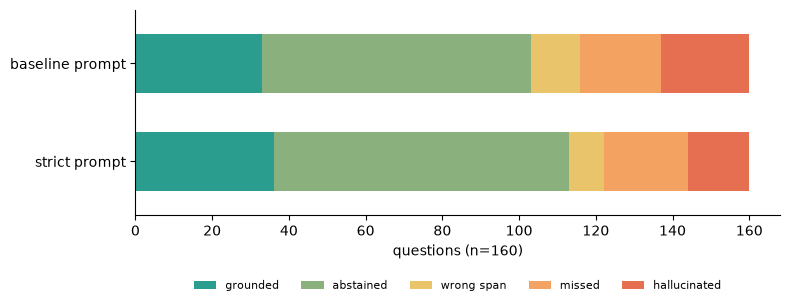

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.4))
cols = ["grounded", "abstained", "wrong span", "missed", "hallucinated"]
comparison[cols].plot.barh(ax=ax, stacked=True, width=0.6,
                           color=["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261", "#e76f51"])
ax.set_xlabel(f"questions (n={N_EVAL})")
ax.legend(frameon=False, ncols=5, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.42))
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## What to take from this

**The demo was not wrong, it was unrepresentative.** The pipeline answers well-posed questions
about clauses that exist. That is a real capability and it is a fraction of the job.

**Abstention is a feature you have to ask for.** On a corpus where most questions have no
answer, a model's willingness to produce something plausible is the dominant failure mode, and
it is invisible until you measure against questions that have no answer.

**"Accuracy" is not one number.** Retrieval missing the passage and the model ignoring the
passage are different bugs, in this run 21 and 15 of them. Separating them takes ground truth
at the span level, and it turns "the RAG isn't very good" into a specific thing to go fix.

**Measure the thing you are going to change.** The prompt edit above took a minute and moved
64.4% to 70.6% — fabrications fell from 23 to 16 and grounded answers rose from 33 to 36,
while one more question got an over-cautious "not found". A real gain with a real cost, and
neither is visible without the harness. The harness is the part worth keeping.

## Where to take this

- **Tune chunk size and overlap against retrieval recall.** 1200/200 was a guess. The gold
  chunks are already computed, so sweeping it is a loop, not a research project.
- **Add the lexical half.** [`retrieval/01`](../retrieval/01_hybrid_and_filtered.ipynb) shows
  hybrid search beating vector alone on recall — and retrieval recall is the ceiling on
  everything here.
- **Extract the clauses instead of asking every time.** Governing law, parties, dates and
  renewal terms are stable facts about a contract. Pull them once on the write path, store them
  on the document beside the text and the vectors, and most of these questions stop being
  retrieval problems at all — they become a lookup, and the remaining questions get a smaller,
  better-targeted search. That is the next notebook.
- **Use the abstentions.** A system that reliably says "not in this document" can be trusted to
  escalate. One that never says it cannot.

> **On Couchbase AI Data Plane** — the chunking, embedding and indexing above are three
> explicit steps you maintain, and every re-chunk means re-embedding everything. The managed
> service keeps chunks and vectors in step with the documents as they change. What does not
> change is the part this notebook is really about: you still have to measure, and nobody can
> measure it for you.

In [16]:
# Everything this notebook created, in one scope. Uncomment to remove it.
# from cbnb.couchbase_io import drop_demo_data
# drop_demo_data(cluster, BUCKET, SCOPE)